# Style Symbol Cartograms

This guide shows how to use data-driven styling when plotting a symbol cartogram.
The `plot()` method maps any data column to fill color, opacity, edge color,
line width, hatching, or symbol shape — each independently.

The workflow separates **layout** (expensive, run once) from **styling** (fast, experiment freely):
1. `create_layout()` — computes symbol positions; stores them in an immutable `LayoutResult`
2. `layout_result.style()` — applies symbol shapes
3. `cartogram.plot()` — maps data to color, opacity, hatching, labels

In [1]:
import matplotlib.pyplot as plt

import carto_flow.symbol_cartogram as sym
from carto_flow.data import load_us_census
from carto_flow.symbol_cartogram.styling import Styling

gdf = load_us_census(poverty=True)
gdf.head()

,STATE,State Name,Population,Total Poverty,Below Poverty Level,Above Poverty Level,geometry,State Abbreviation,Region,Division,Population (Millions),Population Density,Below Poverty Level %,Above Poverty Level %
0,42,Pennsylvania,12794885,11697147,1354558,10342589,"POLYGON ((1221365.308 206942.185, 1221294.608 ...",PA,Northeast,Middle Atlantic,12.794885,109.040911,0.115802,0.884198
1,06,California,39346023,36223360,4451904,31771456,"MULTIPOLYGON (((-1980516.535 -528034.807, -198...",CA,West,Pacific,39.346023,96.008122,0.122901,0.877099
2,54,West Virginia,1807426,1662817,276138,1386679,"POLYGON ((1100359.479 -138088.343, 1100368.166...",WV,South,South Atlantic,1.807426,28.801063,0.166066,0.833934
3,49,Utah,3151239,2856137,255847,2600290,"POLYGON ((-1495999.422 -140647.737, -1495692.4...",UT,West,Mountain,3.151239,14.331064,0.089578,0.910422
4,36,New York,19514849,17890963,2360844,15530119,"MULTIPOLYGON (((1253672.084 372483.585, 125351...",NY,Northeast,Middle Atlantic,19.514849,153.728484,0.131957,0.868043


## Compute the layout once

`create_layout()` runs the circle packing simulation and returns a `LayoutResult`.
All styling variations below reuse this single result — no re-simulation needed.

In [2]:
layout_result = sym.create_layout(gdf, "Population", layout="topology", size_normalization="total")
cartogram = layout_result.style()

Refining topology:  45%|██▏  | 223/500 [00:00<00:00, 416.70it/s, drift=5.40e-03, jitter=3.73e-02, overlaps=40]


## Color by a numeric column

Pass a column name to `facecolor` together with a colormap.
`vmin` and `vmax` pin the color range.

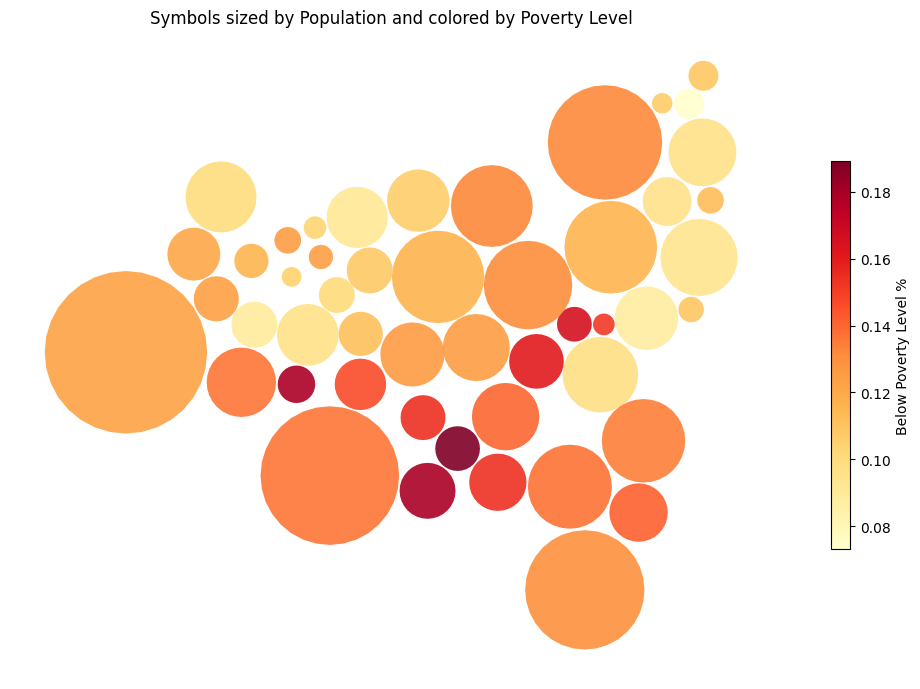

In [3]:
fig, ax = plt.subplots(figsize=(12, 7))

plot = cartogram.plot(
    ax=ax,
    # pass the original DataFrame
    # to have access to the data columns
    source_gdf=gdf,
    # numeric-column-driven face color
    facecolor="Below Poverty Level %",
    cmap="YlOrRd",
    # show colorbar
    legend=True,
    legend_kwds={"shrink": 0.6},
)

ax.set_title("Symbols sized by Population and colored by Poverty Level")
ax.axis("off")

plt.tight_layout()

## Color by a categorical column

Pass a categorical column name and a `color_map` dict that maps each value to a color.

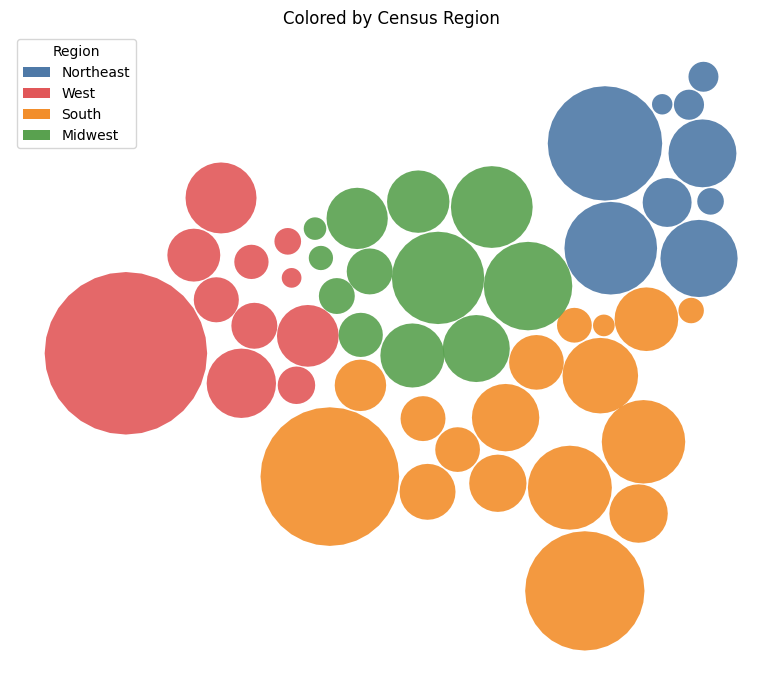

In [4]:
region_colors = {
    "Northeast": "#4e79a7",
    "South": "#f28e2b",
    "Midwest": "#59a14f",
    "West": "#e15759",
}

fig, ax = plt.subplots(figsize=(12, 7))
cartogram.plot(
    ax=ax,
    # pass the original DataFrame
    # to have access to the data columns
    source_gdf=gdf,
    # categorical-column-driven facecolor
    facecolor="Region",
    # specify custom category to color mapping
    cmap=region_colors,
    # show legend
    legend=True,
    legend_kwds={"loc": "upper left", "framealpha": 0.8},
)
ax.set_title("Colored by Census Region")
ax.axis("off")
plt.tight_layout()

## Different symbol shapes per category

Build a `Styling` object and call `set_symbol()` with a boolean mask for each category.
Shape assignment is independent of `plot()` color options — both can vary at the same time.

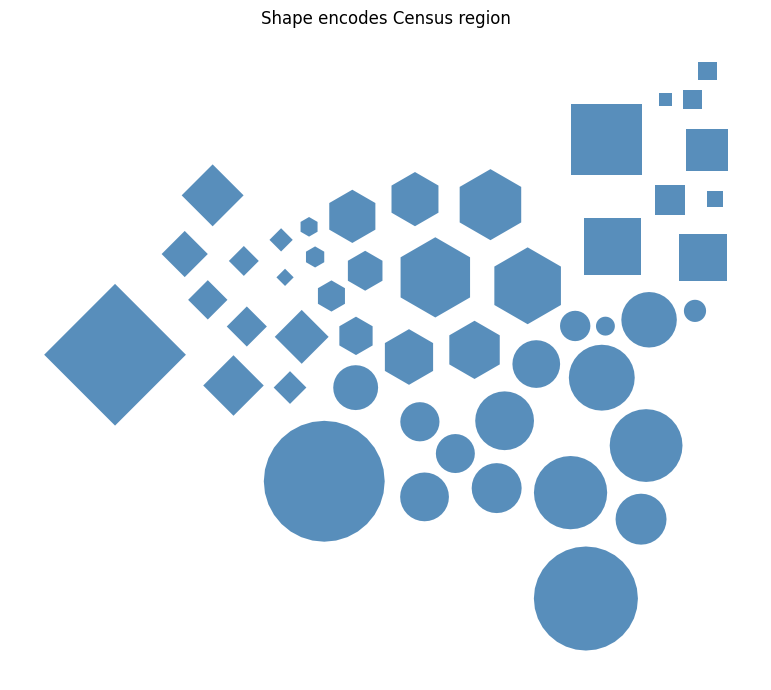

In [5]:
region_shapes = {
    "Northeast": "square",
    "South": "circle",
    "Midwest": "hexagon",
    "West": "diamond",
}

# style symbol shapes
styling = Styling(scale=0.85)
for region, shape in region_shapes.items():
    mask = (gdf["Region"] == region).values
    styling = styling.set_symbol(shape, mask=mask)

# note that cartograms can be restyled
cartogram_shapes = cartogram.restyle(styling=styling)

fig, ax = plt.subplots(figsize=(12, 7))
cartogram_shapes.plot(
    ax=ax,
    # pass the original DataFrame
    # to have access to the data columns
    source_gdf=gdf,
    facecolor="steelblue",
)

ax.set_title("Shape encodes Census region")
ax.axis("off")
plt.tight_layout()

## Data-driven opacity

Pass a column name to `alpha`. `alpha_range` sets the min and max opacity.

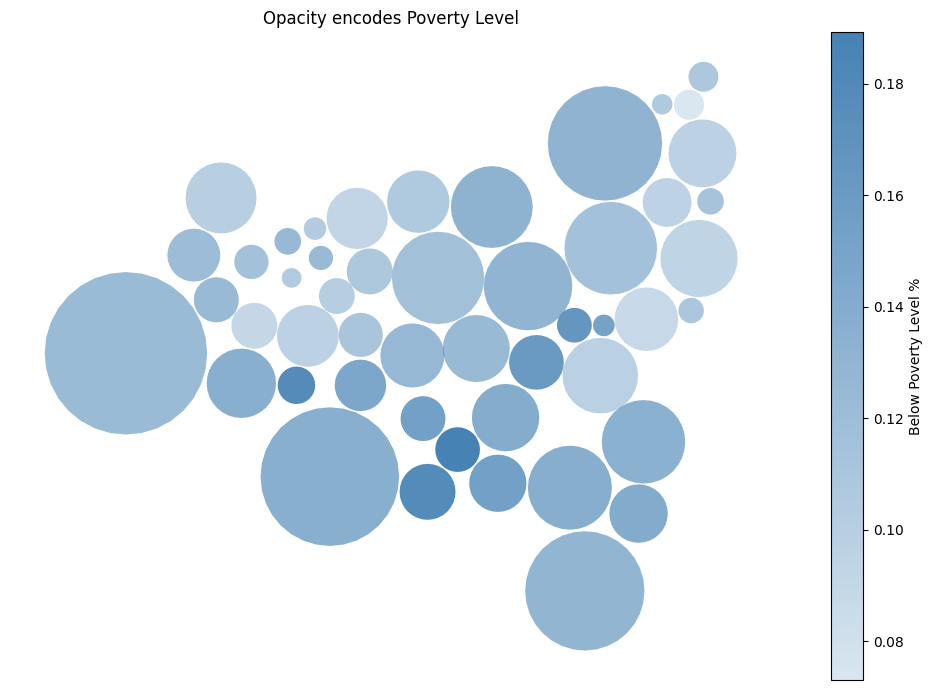

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
cartogram.plot(
    ax=ax,
    # pass the original DataFrame
    # to have access to the data columns
    source_gdf=gdf,
    facecolor="steelblue",
    # numeric-column-driven alpha
    alpha="Below Poverty Level %",
    alpha_range=(0.2, 1.0),
    alpha_legend=True,
)
ax.set_title("Opacity encodes Poverty Level")
ax.axis("off")
plt.tight_layout()

## Data-driven edge color and line width

`edgecolor` accepts a column name plus an optional `edge_cmap`.
`linewidth` accepts a column name plus `linewidth_range`.

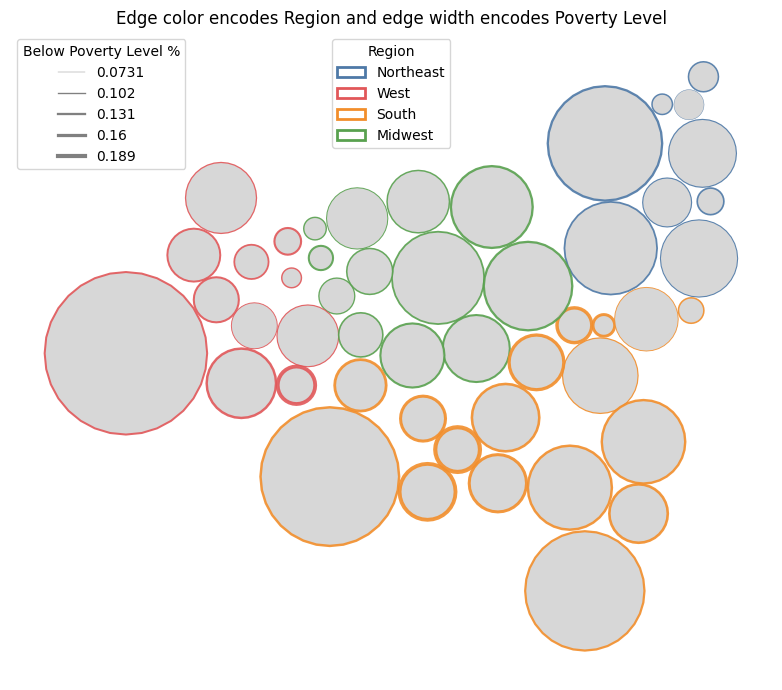

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))
cartogram.plot(
    ax=ax,
    # pass the original DataFrame
    # to have access to the data columns
    source_gdf=gdf,
    facecolor="lightgray",
    # category-column-driven edge color
    # with custom color mapping
    edgecolor="Region",
    edge_cmap=region_colors,
    # numeric-column-driven line width
    linewidth="Below Poverty Level %",
    linewidth_range=(0.3, 3.0),
    # legends
    edge_legend=True,
    edge_legend_kwds={"loc": "upper center"},
    linewidth_legend=True,
    linewidth_legend_kwds={"loc": "upper left"},
)
ax.set_title("Edge color encodes Region and edge width encodes Poverty Level")
ax.axis("off")
plt.tight_layout()

## Hatching

`hatch` accepts a column name and `hatch_map` maps each category to a matplotlib hatch string.
`hatch_legend=True` adds a legend entry for each hatch pattern.

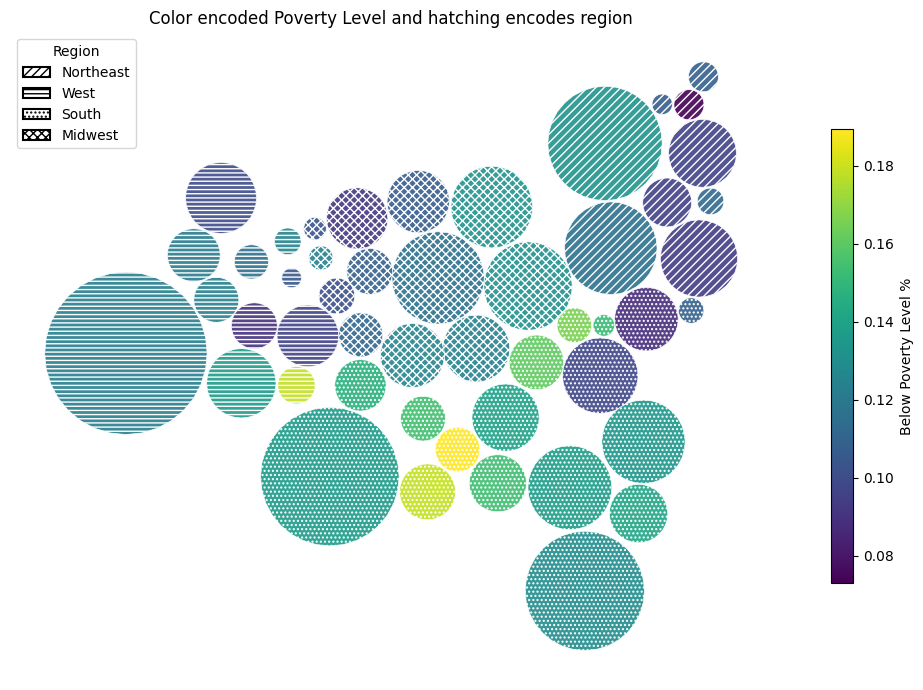

In [8]:
hatch_map = {
    "Northeast": "////",
    "South": "....",
    "Midwest": "xxxx",
    "West": "----",
}

fig, ax = plt.subplots(figsize=(12, 7))
cartogram.plot(
    ax=ax,
    # pass the original DataFrame
    # to have access to the data columns
    source_gdf=gdf,
    facecolor="Below Poverty Level %",
    legend_kwds={"shrink": 0.7},
    hatch="Region",
    hatch_map=hatch_map,
    hatch_legend=True,
    hatch_legend_kwds={"title": "Region", "loc": "upper left"},
    # set edge color for hatching
    edgecolor="white",
)

ax.set_title("Color encoded Poverty Level and hatching encodes region")
ax.axis("off")

plt.tight_layout()

## Labels

`label` adds text from a column. `label_color` and `label_fontsize` can each be
a fixed value or a data column name.

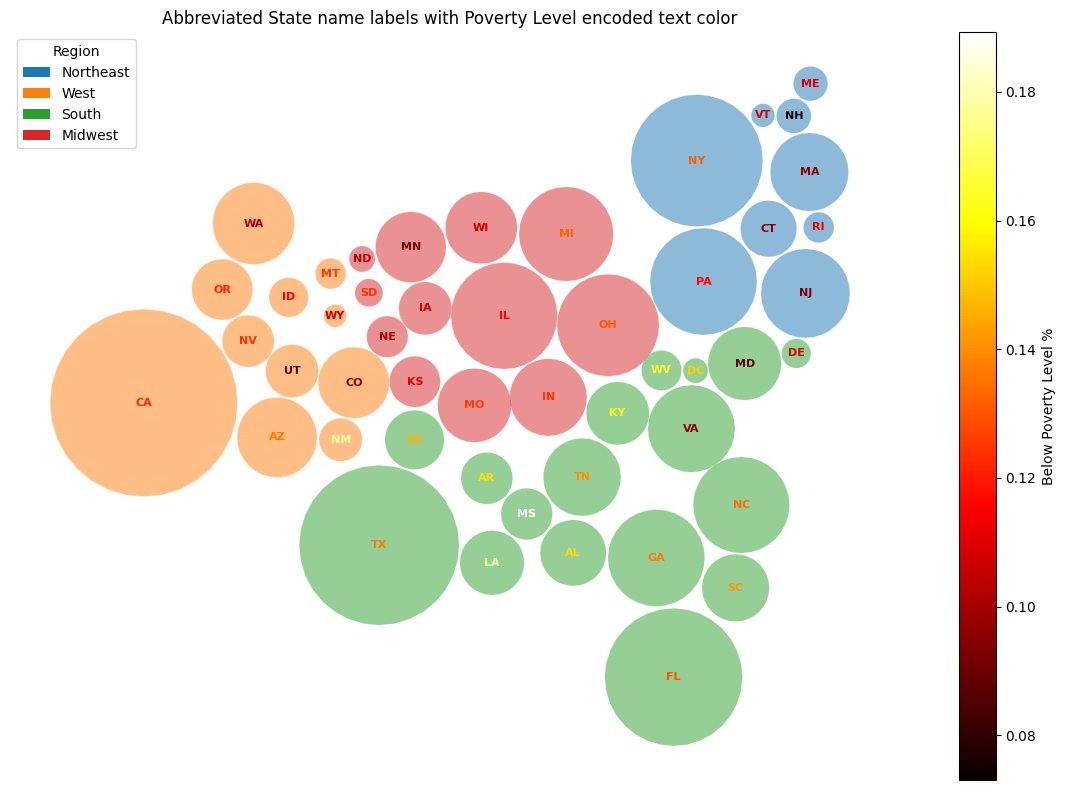

In [9]:
fig, ax = plt.subplots(figsize=(14, 8))
cartogram.plot(
    ax=ax,
    source_gdf=gdf,
    facecolor="Region",
    alpha=0.5,
    # color_map=region_colors,
    edgecolor="white",
    linewidth=0.3,
    label="State Abbreviation",
    label_color="Below Poverty Level %",
    label_cmap="hot",
    label_fontsize=8,
    label_kwargs={"fontweight": "bold"},
    label_legend=True,
)
ax.set_title("Abbreviated State name labels with Poverty Level encoded text color")
ax.axis("off")
plt.tight_layout()